In [1]:
# -*- coding: utf-8 -*-
"""
USPTO-3M Dataset EDA Notebook

This notebook performs Exploratory Data Analysis on the USPTO-3M dataset hosted
on Hugging Face. It focuses on:
1. Text Statistics (Character and Token Lengths)
2. Vocabulary Analysis (Using ModernBERT Tokenizer)
3. Label Analysis (CPC Code Distribution)
4. Total Token Count Estimation
"""


'\nUSPTO-3M Dataset EDA Notebook\n\nThis notebook performs Exploratory Data Analysis on the USPTO-3M dataset hosted\non Hugging Face. It focuses on:\n1. Text Statistics (Character and Token Lengths)\n2. Vocabulary Analysis (Using ModernBERT Tokenizer)\n3. Label Analysis (CPC Code Distribution)\n4. Total Token Count Estimation\n'

In [14]:

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from transformers import AutoTokenizer
from collections import Counter
import math
from tqdm.auto import tqdm # Progress bars

# Plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Dataset and Model Identifiers
DATASET_NAME = "MalavP/USPTO-3M"
# Use the specific ModernBERT tokenizer you used in training/experiments
TOKENIZER_NAME = "answerdotai/ModernBERT-base" 

# Set to True to analyze a smaller subset for faster initial exploration
# Set to False to run on the full dataset (might be slow/memory intensive)
USE_SUBSET = False
SUBSET_SIZE = 100000 # Adjust as needed if USE_SUBSET is True


In [8]:
!which python

~/scratch/miniconda3/envs/data_analysis/bin/python


In [5]:

# %% [markdown]
# ## 2. Load Data
#
# Load the dataset from Hugging Face Hub. We'll primarily work with the training split.

# %%
print(f"Loading dataset: {DATASET_NAME}...")
try:
    # Load the training split
    ds = load_dataset(DATASET_NAME, split="train")
    print("Dataset loaded successfully.")
    print(f"Dataset features: {ds.features}")
    print(f"Number of examples: {len(ds)}")

    if USE_SUBSET:
        print(f"Using a subset of {SUBSET_SIZE} examples for analysis.")
        if SUBSET_SIZE > len(ds):
            print(f"Warning: SUBSET_SIZE ({SUBSET_SIZE}) is larger than dataset size ({len(ds)}). Using full dataset.")
            ds_subset = ds
        else:
            # Shuffle and select is generally good practice for subsets
            ds_subset = ds.shuffle(seed=42).select(range(SUBSET_SIZE))
        dataset_to_analyze = ds_subset
    else:
        print("Using the full dataset for analysis.")
        dataset_to_analyze = ds

except Exception as e:
    print(f"Error loading dataset: {e}")
    # Stop execution if dataset fails to load
    raise

# %% [markdown]
# ### Initial Inspection
# Let's look at the first few examples.


Loading dataset: MalavP/USPTO-3M...
Dataset loaded successfully.
Dataset features: {'cpc_ids': Value(dtype='string', id=None), 'id': Value(dtype='string', id=None), 'date': Value(dtype='string', id=None), 'text': Value(dtype='string', id=None)}
Number of examples: 3198360
Using the full dataset for analysis.


In [8]:

# %%
# Display first 5 examples
print("\nFirst 5 examples:")
# Use ds.select() to avoid loading the whole thing into memory just for display
for i in range(min(5, len(dataset_to_analyze))):
    print(dataset_to_analyze[i])
    print("-" * 20)

# ## 3. Text Statistics
#
# Analyze the length and characteristics of the patent text ('text' field).



First 5 examples:
{'cpc_ids': 'A01H', 'id': '6803509', 'date': '2004-10-12', 'text': 'Seed of corn inbred line designated 9SM990, representative seed of said line having been deposited under ATCC Accession No. PTA-5974.'}
--------------------
{'cpc_ids': 'C11D,Y10S', 'id': '6475976', 'date': '2002-11-05', 'text': 'A hard surface cleaning wipe which comprises approximately:(a) 20 wt. % to 30 wt. % of a nonwoven fabric; and (b) 70 wt. % to 80 wt. % of a liquid cleaning composition being impregnated in said nonwoven fabric, wherein said liquid cleaning composition comprises by weight: (i) 0.01% to 5% of a sulfate anionic surfactant; (ii) 0.01% to 2.0% of a polyhexamethylene-4-biguanide hydrochloride; and (iii) the balance being water.'}
--------------------
{'cpc_ids': 'H03M,H04N', 'id': '7565018', 'date': '2009-07-21', 'text': "1. A method of encoding digital media data in a computing environment comprising a processor and a memory, the method comprising: the processor applying a transf

Calculating char lengths: 100%|██████████| 3198360/3198360 [01:23<00:00, 38285.37it/s]


99th percentile character length threshold: 2957
Removed 31973 outliers (top 1%) for stats and plotting.

--- Character Length Statistics (Top 1% Outliers Removed) ---
Mean: 946.68
Median: 862.00
Min: 1
Max (approx. 99th percentile): 2957.00
Std Dev: 505.96


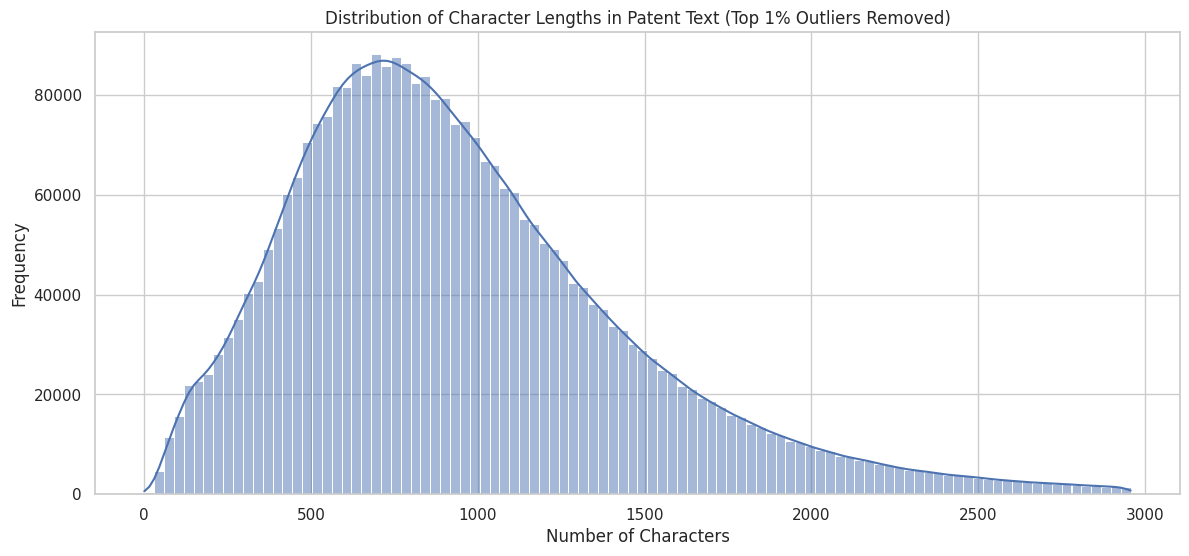

In [17]:
all_char_lengths = []
for example in tqdm(dataset_to_analyze, desc="Calculating char lengths"):
    if 'text' in example and example['text']:
        all_char_lengths.append(len(example['text']))

all_char_lengths = np.array(all_char_lengths)

percentile_99 = np.percentile(all_char_lengths, 99)
print(f"99th percentile character length threshold: {percentile_99:.0f}")

char_lengths_filtered = all_char_lengths[all_char_lengths <= percentile_99]
num_removed = len(all_char_lengths) - len(char_lengths_filtered)
print(f"Removed {num_removed} outliers (top 1%) for stats and plotting.")

print("\n--- Character Length Statistics (Top 1% Outliers Removed) ---")
print(f"Mean: {np.mean(char_lengths_filtered):.2f}")
print(f"Median: {np.median(char_lengths_filtered):.2f}")
print(f"Min: {np.min(char_lengths_filtered)}")
print(f"Max (approx. 99th percentile): {np.max(char_lengths_filtered):.2f}")
print(f"Std Dev: {np.std(char_lengths_filtered):.2f}")

plt.figure(figsize=(14, 6))
sns.histplot(char_lengths_filtered, bins=100, kde=True)
plt.title('Distribution of Character Lengths in Patent Text (Top 1% Outliers Removed)')
plt.xlabel('Number of Characters')
plt.ylabel('Frequency')
plt.show()


Loading tokenizer...
Tokenizer loaded.

Calculating token lengths using 57 CPU cores (this may take a while)...


Calculating token lengths (num_proc=57):  24%|██▎       | 758000/3198360 [00:39<01:44, 23322.70 examples/s]Token indices sequence length is longer than the specified maximum sequence length for this model (8979 > 8192). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (13140 > 8192). Running this sequence through the model will result in indexing errors
Calculating token lengths (num_proc=57):  96%|█████████▌| 3064804/3198360 [02:38<00:06, 19331.34 examples/s]


Error during parallel token length calculation: TextEncodeInput must be Union[TextInputSequence, Tuple[InputSequence, InputSequence]]
Falling back to sequential processing (will be slower)...


Calculating token lengths (sequential fallback):   2%|▏         | 71581/3198360 [00:28<20:33, 2534.24it/s]Token indices sequence length is longer than the specified maximum sequence length for this model (15653 > 8192). Running this sequence through the model will result in indexing errors
Calculating token lengths (sequential fallback): 100%|██████████| 3198360/3198360 [21:35<00:00, 2468.91it/s]


99th percentile token length threshold: 575
Removed 31858 token length outliers (top 1%) for stats and plotting.

--- Token Length Statistics (Top 1% Outliers Removed) ---
Mean: 177.98
Median: 161.00
Min: 1
Max (approx. 99th percentile): 575.00
Std Dev: 93.79


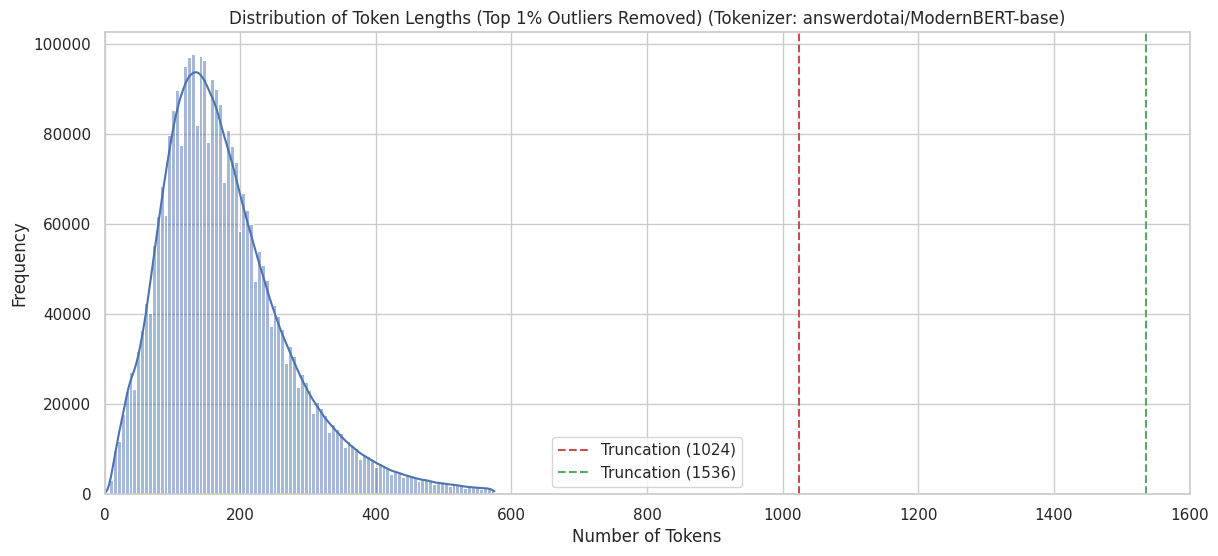

In [20]:
# %%
# --- Token Length Analysis (Parallelized, Outliers Removed) ---
import os # Import os to get CPU count

print("\nLoading tokenizer...")
try:
    # Load the tokenizer once before mapping
    tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_NAME)
    print("Tokenizer loaded.")
except Exception as e:
    print(f"Error loading tokenizer '{TOKENIZER_NAME}': {e}")
    # Can't proceed with token analysis if tokenizer fails
    raise

# Define the function to calculate token lengths for a batch
def calculate_batch_token_lengths(batch):
    # Tokenize the batch of texts. Use the tokenizer directly for batch processing.
    # No padding, no truncation, no special tokens needed for length calculation.
    # Using the tokenizer directly on the batch is often faster than iterating encode.
    tokenized_batch = tokenizer(batch['text'], add_special_tokens=False, truncation=False)
    # Return a dictionary with a new key 'token_length' containing the list of lengths
    return {'token_length': [len(ids) for ids in tokenized_batch['input_ids']]}

# Determine the number of processors to use
num_cpus = os.cpu_count() - 5
# You might want to use slightly fewer than total CPUs to leave resources for other tasks
num_proc_to_use = max(1, num_cpus - 2) if num_cpus else 1 # Use all but 2, or at least 1
print(f"\nCalculating token lengths using {num_proc_to_use} CPU cores (this may take a while)...")

# Apply the function using .map() for parallel processing
try:
    # remove_columns helps save memory if you only need the token lengths
    processed_ds = dataset_to_analyze.map(
        calculate_batch_token_lengths,
        batched=True, # Process data in batches
        num_proc=num_proc_to_use, # Number of processes
        remove_columns=dataset_to_analyze.column_names, # Remove original columns
        desc="Calculating token lengths"
    )
    print("Token length calculation complete.")

    # Extract all token lengths into a NumPy array
    all_token_lengths = np.array(processed_ds['token_length'])

except Exception as e:
    print(f"Error during parallel token length calculation: {e}")
    print("Falling back to sequential processing (will be slower)...")
    # --- Fallback Sequential Calculation (if parallel fails) ---
    all_token_lengths = []
    for example in tqdm(dataset_to_analyze, desc="Calculating token lengths (sequential fallback)"):
        if example and 'text' in example and example['text']:
            text_to_encode = example['text']
            token_ids = tokenizer.encode(text_to_encode, add_special_tokens=False, truncation=False)
            all_token_lengths.append(len(token_ids))
    all_token_lengths = np.array(all_token_lengths)
    # --- End Fallback ---


# --- Calculate 99th percentile threshold for tokens ---
if len(all_token_lengths) > 0:
    token_percentile_99 = np.percentile(all_token_lengths, 99)
    print(f"99th percentile token length threshold: {token_percentile_99:.0f}")

    # --- Filter out the top 1% outliers ---
    token_lengths_filtered = all_token_lengths[all_token_lengths <= token_percentile_99]
    num_removed = len(all_token_lengths) - len(token_lengths_filtered)
    print(f"Removed {num_removed} token length outliers (top 1%) for stats and plotting.")
else:
    print("No valid token lengths found to process.")
    token_lengths_filtered = np.array([]) # Ensure it's empty if no data

# --- Recalculate Statistics on Filtered Token Length Data ---
if len(token_lengths_filtered) > 0:
    print("\n--- Token Length Statistics (Top 1% Outliers Removed) ---")
    print(f"Mean: {np.mean(token_lengths_filtered):.2f}")
    print(f"Median: {np.median(token_lengths_filtered):.2f}")
    print(f"Min: {np.min(token_lengths_filtered)}")
    print(f"Max (approx. 99th percentile): {np.max(token_lengths_filtered):.2f}")
    print(f"Std Dev: {np.std(token_lengths_filtered):.2f}")

    # Plot token length distribution (Filtered Data)
    plt.figure(figsize=(14, 6))
    sns.histplot(token_lengths_filtered, bins=100, kde=True) # Use filtered data for plot
    plt.title(f'Distribution of Token Lengths (Top 1% Outliers Removed) (Tokenizer: {TOKENIZER_NAME})')
    plt.xlabel('Number of Tokens')
    plt.ylabel('Frequency')
    # plt.yscale('log') # Keep log scale for y-axis if desired

    plt.axvline(x=1024, color='r', linestyle='--', label='Truncation (1024)')
    plt.axvline(x=1536, color='g', linestyle='--', label='Truncation (1536)')
    # Adjust plot limits if outliers made the scale too large previously
    plt.xlim(left=0, right=max(token_percentile_99 * 1.05, 1600)) # Adjust x-limit to focus on relevant range
    plt.legend()
    plt.show()
else:
    print("No token length data remains after filtering (or no data initially). Cannot calculate stats or plot.")

In [21]:
token_lengths = all_token_lengths # Use the original token lengths for further analysis
# %%
# --- Effect of Truncation ---
truncation_lengths = [128, 512, 1024, 1536] # Add others if relevant
print("\n--- Percentage of Patents Affected by Truncation ---")
for length in truncation_lengths:
    affected_count = np.sum(token_lengths > length)
    percentage = (affected_count / len(token_lengths)) * 100
    print(f"Tokens > {length}: {affected_count} patents ({percentage:.2f}%)")




--- Percentage of Patents Affected by Truncation ---
Tokens > 128: 2141778 patents (66.96%)
Tokens > 512: 49118 patents (1.54%)
Tokens > 1024: 6304 patents (0.20%)
Tokens > 1536: 2989 patents (0.09%)


In [ ]:

# %% [markdown]
# ## 4. Vocabulary Analysis
#
# Analyze the tokens generated by the ModernBERT tokenizer on a sample of the data. This helps understand how well the tokenizer covers the patent domain vocabulary.
#
# *Note: Tokenizing the entire 3M dataset might be very time/memory consuming. We'll use a sample.*


In [22]:

# %%
VOCAB_SAMPLE_SIZE = 50000 # Number of patents to sample for vocab analysis
if VOCAB_SAMPLE_SIZE > len(dataset_to_analyze):
    print(f"Warning: VOCAB_SAMPLE_SIZE ({VOCAB_SAMPLE_SIZE}) > dataset size. Using full dataset for vocab.")
    vocab_sample_indices = range(len(dataset_to_analyze))
else:
    print(f"Sampling {VOCAB_SAMPLE_SIZE} patents for vocabulary analysis...")
    # Create indices for sampling
    np.random.seed(42)
    vocab_sample_indices = np.random.choice(len(dataset_to_analyze), VOCAB_SAMPLE_SIZE, replace=False)

print("Tokenizing sample and counting token frequencies...")
token_counts = Counter()
unknown_token_count = 0
total_tokens_in_sample = 0

# Get UNK token if it exists
unk_token_id = tokenizer.unk_token_id if hasattr(tokenizer, 'unk_token_id') else None
unk_token = tokenizer.unk_token if hasattr(tokenizer, 'unk_token') else None
print(f"UNK token: {unk_token} (ID: {unk_token_id})" if unk_token else "Tokenizer does not seem to have an UNK token.")

for idx in tqdm(vocab_sample_indices, desc="Analyzing Vocabulary"):
    example = dataset_to_analyze[int(idx)] # Need int() if indices are numpy int64
    text_to_encode = example['text']
    # Tokenize without special tokens for pure vocab analysis
    token_ids = tokenizer.encode(text_to_encode, add_special_tokens=False, truncation=False)
    token_counts.update(token_ids)
    total_tokens_in_sample += len(token_ids)
    if unk_token_id is not None:
        unknown_token_count += token_ids.count(unk_token_id)

print(f"\nTotal tokens processed in sample: {total_tokens_in_sample}")
print(f"Unique token IDs found in sample: {len(token_counts)}")
print(f"Tokenizer vocabulary size: {tokenizer.vocab_size}")

if unk_token_id is not None:
    print(f"Count of UNK token ('{unk_token}') in sample: {unknown_token_count}")
    if total_tokens_in_sample > 0:
        unk_percentage = (unknown_token_count / total_tokens_in_sample) * 100
        print(f"Percentage of UNK tokens in sample: {unk_percentage:.4f}%")
else:
    print("No UNK token analysis performed (tokenizer might not use explicit UNK).")


Sampling 50000 patents for vocabulary analysis...
Tokenizing sample and counting token frequencies...
UNK token: [UNK] (ID: 50280)


Analyzing Vocabulary: 100%|██████████| 50000/50000 [00:23<00:00, 2112.79it/s]


Total tokens processed in sample: 9246287
Unique token IDs found in sample: 26161
Tokenizer vocabulary size: 50280
Count of UNK token ('[UNK]') in sample: 0
Percentage of UNK tokens in sample: 0.0000%


In [23]:


# %%
# --- Most Common Tokens ---
N_MOST_COMMON = 30
print(f"\n--- Top {N_MOST_COMMON} Most Common Token IDs and Tokens ---")
most_common_token_ids = token_counts.most_common(N_MOST_COMMON)

# Decode IDs back to tokens
# Handle potential errors during decoding
decoded_tokens = []
for token_id, count in most_common_token_ids:
    try:
        # Use decode, skipping special tokens just in case they sneak in somehow
        token_str = tokenizer.decode([token_id], skip_special_tokens=True)
        # Handle cases where decode might return empty string for some control tokens
        if not token_str and len(tokenizer.convert_ids_to_tokens([token_id])) > 0 :
             token_str = tokenizer.convert_ids_to_tokens([token_id])[0] # Fallback to direct conversion
        decoded_tokens.append((token_str, token_id, count))
    except Exception as e:
        print(f"Error decoding token ID {token_id}: {e}")
        decoded_tokens.append(("[DECODING ERROR]", token_id, count))


for token_str, token_id, count in decoded_tokens:
    print(f"Token: '{token_str}' (ID: {token_id}) - Count: {count}")




--- Top 30 Most Common Token IDs and Tokens ---
Token: ' the' (ID: 253) - Count: 598948
Token: ' a' (ID: 247) - Count: 437512
Token: ' of' (ID: 273) - Count: 326205
Token: ',' (ID: 13) - Count: 301618
Token: ' and' (ID: 285) - Count: 243503
Token: ' to' (ID: 281) - Count: 202777
Token: ' said' (ID: 753) - Count: 172828
Token: ';' (ID: 28) - Count: 146712
Token: '.' (ID: 15) - Count: 113100
Token: ' in' (ID: 275) - Count: 101818
Token: ' first' (ID: 806) - Count: 101550
Token: ' an' (ID: 271) - Count: 92016
Token: '-' (ID: 14) - Count: 88412
Token: ' second' (ID: 1273) - Count: 80232
Token: ' for' (ID: 323) - Count: 80106
Token: ' is' (ID: 310) - Count: 79026
Token: ' at' (ID: 387) - Count: 66787
Token: ' comprising' (ID: 11616) - Count: 61987
Token: ' one' (ID: 581) - Count: 57151
Token: ' from' (ID: 432) - Count: 56750
Token: ' wherein' (ID: 10646) - Count: 55989
Token: ':' (ID: 27) - Count: 55311
Token: ' with' (ID: 342) - Count: 54964
Token: '1' (ID: 18) - Count: 47951
Token: ')' (

In [ ]:

# %% [markdown]
# ## 5. Label Analysis (CPC Codes)
#
# Analyze the distribution and characteristics of the patent classification labels ('cpc_ids' field).

# %%


In [24]:

print("\nAnalyzing CPC labels...")

all_labels_flat = []
labels_per_patent = []

for example in tqdm(dataset_to_analyze, desc="Processing labels"):
    patent_labels = example['cpc_ids']
    if patent_labels: # Check if the list is not empty
        all_labels_flat.extend(patent_labels)
        labels_per_patent.append(len(patent_labels))
    else:
        labels_per_patent.append(0) # Record patents with no labels

print(f"\nTotal number of label instances: {len(all_labels_flat)}")
label_counts = Counter(all_labels_flat)
print(f"Number of unique CPC codes (classes): {len(label_counts)}")



Analyzing CPC labels...


Processing labels: 100%|██████████| 3198360/3198360 [01:28<00:00, 36173.02it/s]


Total number of label instances: 27472585
Number of unique CPC codes (classes): 33



--- Label Frequency Statistics ---
Mean frequency: 832502.58
Median frequency: 461309.00
Min frequency: 1946
Max frequency: 4320969
Std Dev of frequency: 943700.98


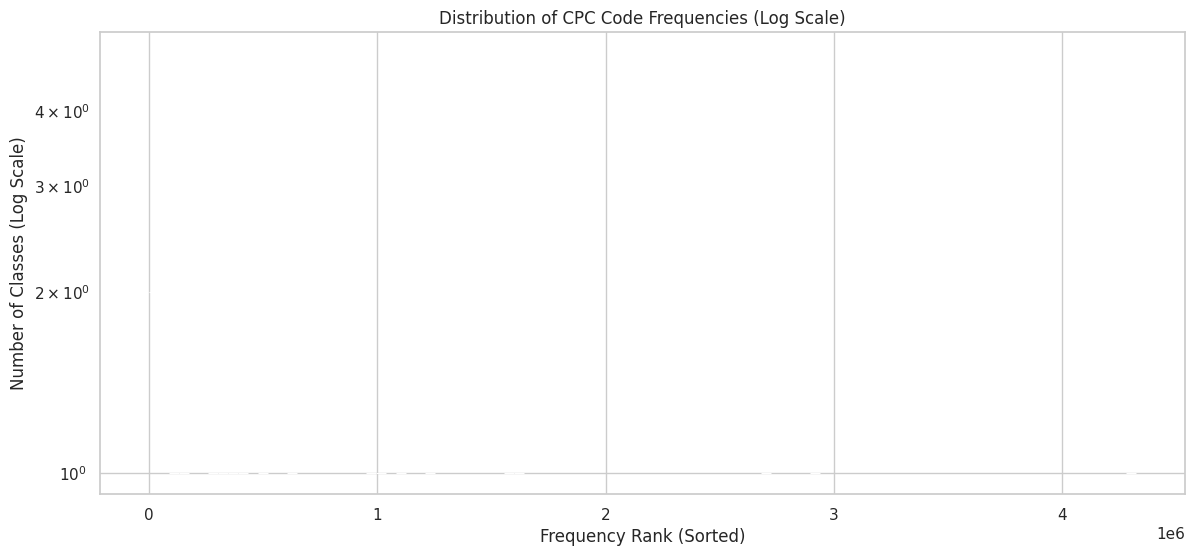

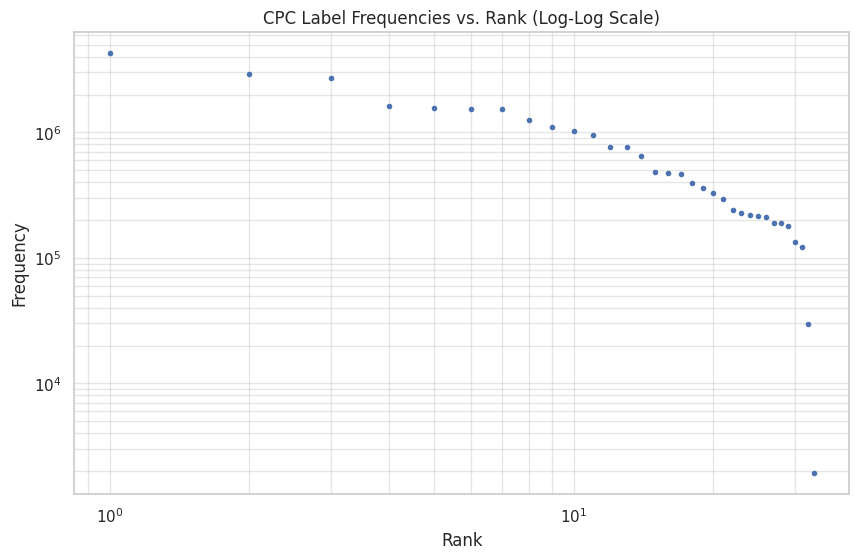

In [25]:

# %%
# --- Label Frequency Distribution ---
print("\n--- Label Frequency Statistics ---")
frequencies = np.array(list(label_counts.values()))
print(f"Mean frequency: {np.mean(frequencies):.2f}")
print(f"Median frequency: {np.median(frequencies):.2f}")
print(f"Min frequency: {np.min(frequencies)}")
print(f"Max frequency: {np.max(frequencies)}")
print(f"Std Dev of frequency: {np.std(frequencies):.2f}")

# Plot label frequency distribution (Log scale is essential here)
plt.figure(figsize=(14, 6))
sns.histplot(frequencies, bins=100, log_scale=(False, True)) # Log scale for y-axis (frequency)
plt.title('Distribution of CPC Code Frequencies (Log Scale)')
plt.xlabel('Frequency Rank (Sorted)') # Or 'Frequency' if not sorting bins
plt.ylabel('Number of Classes (Log Scale)')
plt.show()

# Plot frequencies on log-log scale (Zipf's law plot)
sorted_freqs = sorted(frequencies, reverse=True)
ranks = np.arange(1, len(sorted_freqs) + 1)
plt.figure(figsize=(10, 6))
plt.loglog(ranks, sorted_freqs, marker=".", linestyle="none")
plt.title("CPC Label Frequencies vs. Rank (Log-Log Scale)")
plt.xlabel("Rank")
plt.ylabel("Frequency")
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()


# %%


In [26]:
# --- Top and Bottom Labels ---
N_TOP_BOTTOM = 20
print(f"\n--- Top {N_TOP_BOTTOM} Most Frequent CPC Codes ---")
for label, count in label_counts.most_common(N_TOP_BOTTOM):
    print(f"'{label}': {count}")

print(f"\n--- Bottom {N_TOP_BOTTOM} Least Frequent CPC Codes ---")
# .most_common() returns all items if n > len(counter)
# To get least common, slice from the end
least_common = label_counts.most_common()[::-1][:N_TOP_BOTTOM]
for label, count in least_common:
     print(f"'{label}': {count}")




--- Top 20 Most Frequent CPC Codes ---
'0': 4320969
',': 2935829
'1': 2708622
'B': 1608996
'G': 1572060
'6': 1546225
'H': 1526194
'2': 1250612
'F': 1098704
'C': 1021746
'4': 959995
'A': 765657
'Y': 761154
'L': 646054
'K': 480901
'D': 474726
'3': 461309
'T': 392467
'N': 361687
'5': 326915

--- Bottom 20 Least Frequent CPC Codes ---
'Z': 1946
'V': 29805
'W': 122080
'R': 132842
'Q': 178098
'E': 188821
'9': 189845
'8': 210051
'J': 216297
'P': 220853
'M': 226001
'S': 241289
'7': 293835
'5': 326915
'N': 361687
'T': 392467
'3': 461309
'D': 474726
'K': 480901
'L': 646054



--- Statistics for Number of Labels Per Patent ---
Mean: 8.59
Median: 9.00
Min: 4
Max: 119
Std Dev: 6.12
Patents with 0 labels: 0


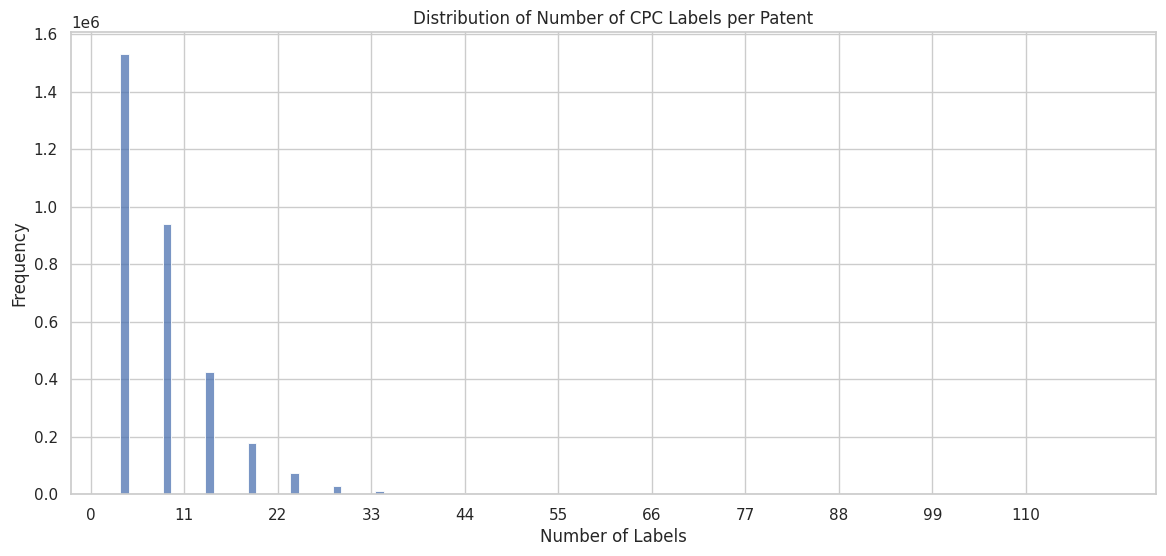

In [27]:

# %%
# --- Labels Per Patent ---
labels_per_patent = np.array(labels_per_patent)
print("\n--- Statistics for Number of Labels Per Patent ---")
print(f"Mean: {np.mean(labels_per_patent):.2f}")
print(f"Median: {np.median(labels_per_patent):.2f}")
print(f"Min: {np.min(labels_per_patent)}")
print(f"Max: {np.max(labels_per_patent)}")
print(f"Std Dev: {np.std(labels_per_patent):.2f}")
print(f"Patents with 0 labels: {np.sum(labels_per_patent == 0)}")

# Plot distribution of labels per patent
plt.figure(figsize=(14, 6))
# Use discrete bins centered on integers
max_lbl = int(np.max(labels_per_patent))
sns.histplot(labels_per_patent, bins=np.arange(max_lbl + 2) - 0.5, discrete=True, stat="count")
plt.title('Distribution of Number of CPC Labels per Patent')
plt.xlabel('Number of Labels')
plt.ylabel('Frequency')
plt.xticks(np.arange(0, max_lbl + 1, step=max(1, max_lbl // 10))) # Adjust tick step
# Consider limiting x-axis if max is very large: plt.xlim(-0.5, 20.5)
plt.show()


In [ ]:

# %% [markdown]
# ## 6. Total Token Count Estimation
#
# Estimate the total number of tokens in the dataset to compare its size relative to ModernBERT's pretraining corpus (approx. 2 Trillion tokens). We use the average token length calculated earlier.

# %%


In [33]:
# sum(all_token_lengths)
# in billion
total_token_count = np.sum(all_token_lengths)
print(f"total token count in dataset: {total_token_count / 1e9:.4f} billion tokens")

total token count in dataset: 0.5950 billion tokens


In [30]:

print("\n--- Estimating Total Token Count ---")

# Use the mean token length calculated from the full dataset analysis
# if 'token_lengths' in locals() and len(token_lengths) == len(dataset_to_analyze):
mean_tokens_per_patent = np.mean(token_lengths)
total_patents = len(dataset_to_analyze) # Use the size of the analyzed set

estimated_total_tokens = mean_tokens_per_patent * total_patents

print(f"Using dataset size: {total_patents}")
print(f"Mean tokens per patent: {mean_tokens_per_patent:.2f}")
print(f"Estimated total tokens in dataset: {estimated_total_tokens:,.0f}")

# Comparison with ModernBERT pretraining data (approx 2T tokens)
modernbert_training_tokens = 2e12 # 2 Trillion
print(f"ModernBERT pretraining tokens (approx): {modernbert_training_tokens:,.0f}")

ratio = estimated_total_tokens / modernbert_training_tokens
print(f"USPTO-3M estimated token count is approx {ratio:.4f} ({ratio*100:.2f}%) of ModernBERT's pretraining data.")

# Estimate in Billions of tokens
tokens_billion = estimated_total_tokens / 1e9
print(f"USPTO-3M estimated token count: ~{tokens_billion:.2f} Billion tokens")

# else:
#     print("Token lengths were not calculated for the full dataset. Cannot estimate total tokens accurately.")
#     print("Re-run Section 3 (Token Length Analysis) on the full dataset (USE_SUBSET = False).")



--- Estimating Total Token Count ---
Using dataset size: 3198360
Mean tokens per patent: 186.04
Estimated total tokens in dataset: 595,013,423
ModernBERT pretraining tokens (approx): 2,000,000,000,000
USPTO-3M estimated token count is approx 0.0003 (0.03%) of ModernBERT's pretraining data.
USPTO-3M estimated token count: ~0.60 Billion tokens


In [ ]:


# %% [markdown]
# ## 7. Summary & Conclusion
#
# Briefly summarize the key findings from the EDA.
# - Text Length: (e.g., Highly variable, many patents truncated at 1024/1536?)
# - Vocabulary: (e.g., Good coverage by tokenizer? Significant UNK rate? Common domain terms?)
# - Labels: (e.g., Extreme class imbalance confirmed? Average labels per patent? Any patents without labels?)
# - Dataset Size: (e.g., Significantly smaller than pretraining corpus?)
#
# These insights can inform modeling decisions (handling long texts, class imbalance strategies, value of domain pretraining).

# %%
print("\nEDA Complete.")